In [19]:
# %%
import sys
sys.path.insert(0, '..')
import helper_functions
from constants import *

import eelbrain
import mne
import numpy as np
import scipy.io
import matplotlib.pyplot as plt

In [20]:
# %%
SUBJECT = 'S1'
TRIAL   = 4
SENSOR  = 'Cz'
TSTOP   = 10.0

In [21]:
# %%
# MNE setup
montage  = mne.channels.make_standard_montage('biosemi64')
ch_names = montage.ch_names + ['EXG1', 'EXG2']
ch_types = ['eeg'] * 64 + ['misc', 'misc']
info     = mne.create_info(ch_names, EEG_SAMPLING_RATE, ch_types)
info.set_montage(montage, on_missing='ignore')

<Info | 8 non-empty values
 bads: []
 ch_names: Fp1, AF7, AF3, F1, F3, F5, F7, FT7, FC5, FC3, FC1, C1, C3, C5, ...
 chs: 64 EEG, 2 misc
 custom_ref_applied: False
 dig: 67 items (3 Cardinal, 64 EEG)
 highpass: 0.0 Hz
 lowpass: 32.0 Hz
 meas_date: unspecified
 nchan: 66
 projs: []
 sfreq: 64.0 Hz
>

In [22]:
# %%
# Load subject data
subject_data_file = helper_functions.get_subject_data_file(SUBJECT)
mat  = scipy.io.loadmat(subject_data_file, squeeze_me=True, struct_as_record=False)
data = mat['data']


# EEG PREPROCESSING

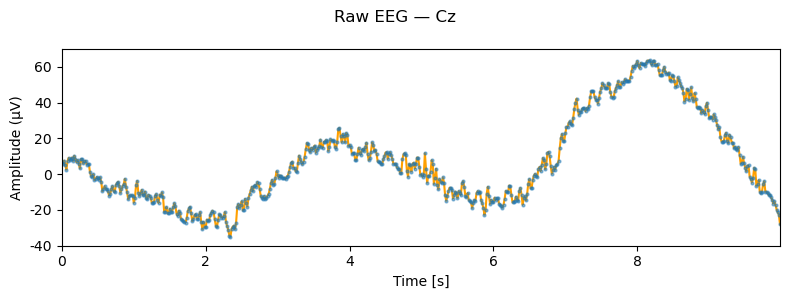

In [ ]:
# %%
# --- Step 1: Raw EEG ---
trial = data.eeg[TRIAL]
raw   = mne.io.RawArray(np.array(trial).T * 1e-6, info, verbose=False)

eeg_raw    = eelbrain.load.mne.raw_ndvar(raw).sub(time=(0, TSTOP))
eeg_sensor = eeg_raw.sub(sensor=SENSOR)

fig, ax = plt.subplots(figsize=(8, 3))
eelbrain.plot.UTS(eeg_sensor, axes=ax, ylabel='Amplitude (µV)', title=f'Raw EEG — {SENSOR}')
ax.plot(eeg_sensor.time, eeg_sensor.x, 'o', markersize=2, alpha=0.5)
fig.tight_layout()
fig.savefig(FIGURES_DIR / f'{FUGLSANG}_fuglsang_preproc_1_raw_eeg.pdf', bbox_inches='tight')
plt.show()

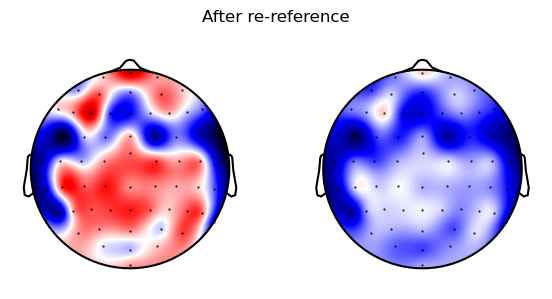

In [ ]:
# %%
# --- Step 2: Re-referencing ---
raw.set_eeg_reference(['EXG1', 'EXG2'])
eeg_ref = eelbrain.load.mne.raw_ndvar(raw).sub(time=(0, TSTOP))

fig, axes = plt.subplots(1, 2, figsize=(6, 3))
eelbrain.plot.Topomap(eeg_raw.mean('time'),  axes=axes[0], clip='circle', title='Before re-reference')
eelbrain.plot.Topomap(eeg_ref.mean('time'),  axes=axes[1], clip='circle', title='After re-reference')
fig.tight_layout()
fig.savefig(FIGURES_DIR / f'{FUGLSANG}_preproc_2_reref_topomap.pdf', bbox_inches='tight')
plt.show()

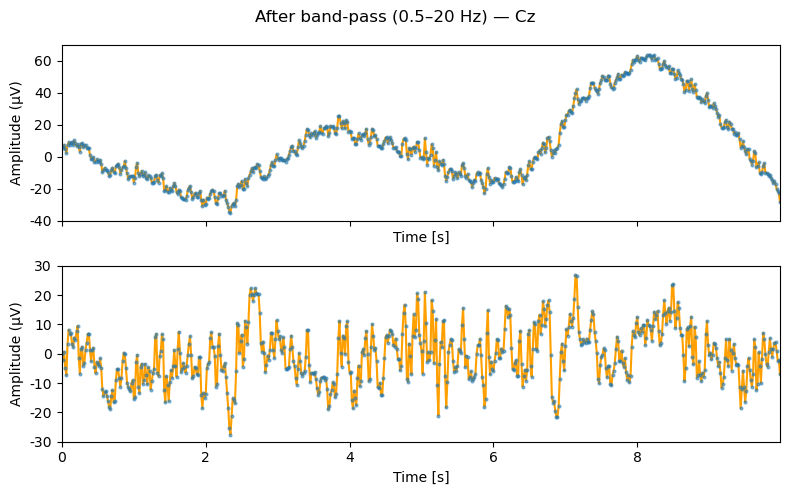

In [ ]:
# %%
# --- Step 3: Band-pass filter ---
raw.filter(EEG_BANDPASS_FILTER_LOW, EEG_BANDPASS_FILTER_HIGH, verbose=False)
eeg_filt = eelbrain.load.mne.raw_ndvar(raw).sub(time=(0, TSTOP)).sub(sensor=SENSOR)

fig, axes = plt.subplots(2, 1, figsize=(8, 5), sharex=True)
eelbrain.plot.UTS(eeg_sensor, axes=axes[0], ylabel='Amplitude (µV)', title=f'Before band-pass — {SENSOR}')
eelbrain.plot.UTS(eeg_filt,   axes=axes[1], ylabel='Amplitude (µV)', title=f'After band-pass ({EEG_BANDPASS_FILTER_LOW}–{EEG_BANDPASS_FILTER_HIGH} Hz) — {SENSOR}')
for ax in axes:
    ax.plot(*([eeg_sensor.time, eeg_sensor.x] if ax == axes[0] else [eeg_filt.time, eeg_filt.x]),
            'o', markersize=2, alpha=0.5)
fig.tight_layout()
fig.savefig(FIGURES_DIR / f'{FUGLSANG}_preproc_3_bandpass.pdf', bbox_inches='tight')
plt.show()

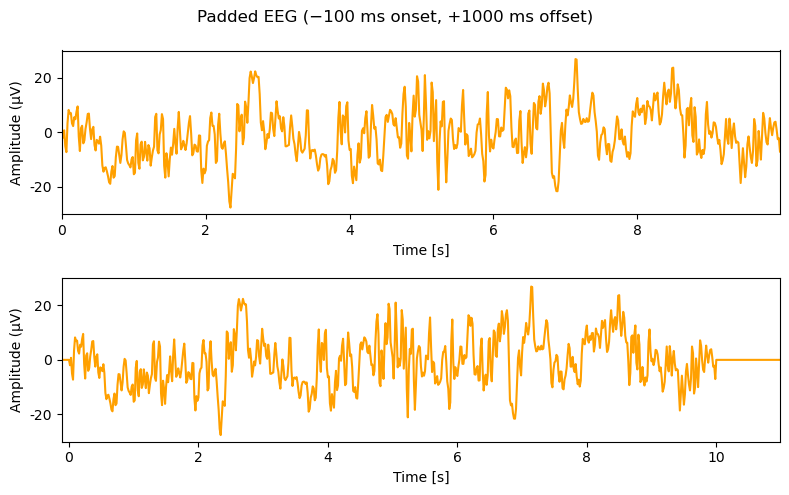

In [ ]:
# %%
# --- Step 4: Padding ---
eeg_padded = eelbrain.pad(eeg_filt, tstart=-PADDING_ONSET, tstop=eeg_filt.time.tstop + PADDING_OFFSET)

fig, axes = plt.subplots(2, 1, figsize=(8, 5), sharex=False)
eelbrain.plot.UTS(eeg_filt,   axes=axes[0], ylabel='Amplitude (µV)', title='Unpadded EEG')
eelbrain.plot.UTS(eeg_padded, axes=axes[1], ylabel='Amplitude (µV)', title=f'Padded EEG (−{int(PADDING_ONSET*1000)} ms onset, +{int(PADDING_OFFSET*1000)} ms offset)')
fig.tight_layout()
fig.savefig(FIGURES_DIR / f'{FUGLSANG}_preproc_4_padding.pdf', bbox_inches='tight')
plt.show()

# AUDIO / PREDICTOR PREPROCESSING

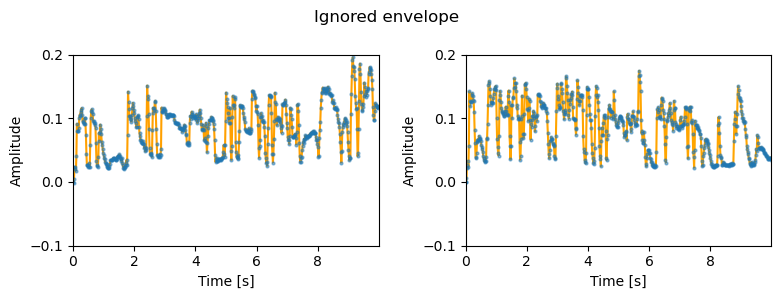

In [ ]:
# %%
# --- Step 5: Envelopes ---
att_ndvar   = eelbrain.NDVar(data.wavA[TRIAL], dims=(eelbrain.UTS(0, 1 / data.fsample.wavA, len(data.wavA[TRIAL])),), name='attended').sub(time=(0, TSTOP))
ign_ndvar   = eelbrain.NDVar(data.wavB[TRIAL], dims=(eelbrain.UTS(0, 1 / data.fsample.wavA, len(data.wavB[TRIAL])),), name='ignored').sub(time=(0, TSTOP))

fig, axes = plt.subplots(1, 2, figsize=(8, 3))
eelbrain.plot.UTS(att_ndvar, axes=axes[0], title='Attended envelope',  ylabel='Amplitude')
eelbrain.plot.UTS(ign_ndvar, axes=axes[1], title='Ignored envelope',   ylabel='Amplitude', color='orange')
for ax, ndvar in zip(axes, [att_ndvar, ign_ndvar]):
    ax.plot(ndvar.time, ndvar.x, 'o', markersize=2, alpha=0.5)
fig.tight_layout()
fig.savefig(FIGURES_DIR / f'{FUGLSANG}_preproc_5_envelopes.pdf', bbox_inches='tight')
plt.show()

Loaded 60 trials


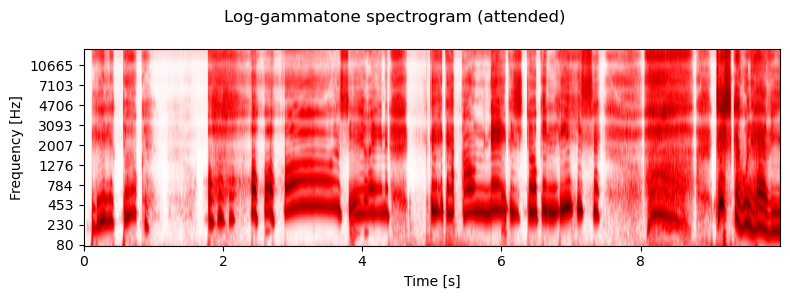

In [ ]:
# %%
# --- Step 6: Gammatone spectrogram ---
stimulus_name = helper_functions.get_trials()[TRIAL]['attended']
gt     = eelbrain.load.unpickle(STIMULUS_DIR / f'{stimulus_name}-gammatone.pickle')
gt_log = (gt + 1).log()
gt_sub = gt_log.sub(time=(0, TSTOP))

fig, ax = plt.subplots(figsize=(8, 3))
eelbrain.plot.Array(gt_sub, axes=ax, title='Log-gammatone spectrogram (attended)')
fig.tight_layout()
fig.savefig(FIGURES_DIR / f'{FUGLSANG}_preproc_6_gammatone.pdf', bbox_inches='tight')
plt.show()

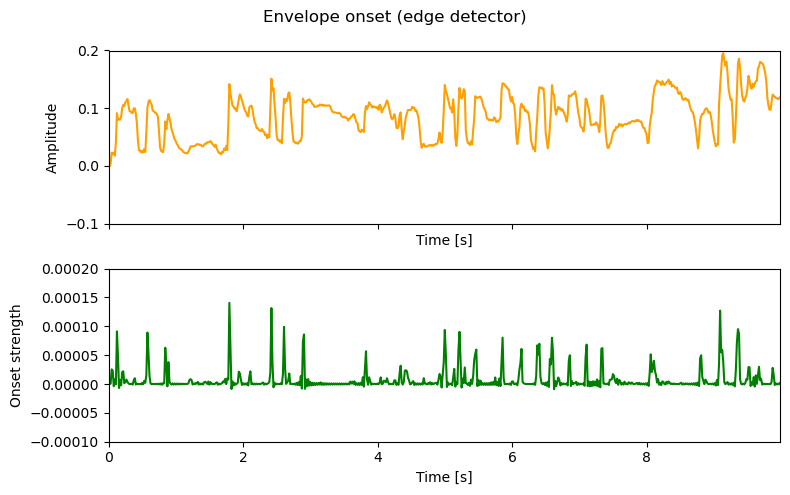

In [ ]:
# %%
# --- Step 7: Envelope onset (edge detector) ---
fdim      = eelbrain.Scalar('frequency', [0])
att_2d    = eelbrain.NDVar(att_ndvar.x[None, :], dims=(fdim, att_ndvar.time))
att_1000  = eelbrain.resample(att_2d, 1000)
att_onset = eelbrain.edge_detector(att_1000, c=30)
att_onset = eelbrain.resample(att_onset, EEG_SAMPLING_RATE).mean('frequency')

fig, axes = plt.subplots(2, 1, figsize=(8, 5), sharex=True)
eelbrain.plot.UTS(att_ndvar,   axes=axes[0], ylabel='Amplitude',   title='Attended envelope')
eelbrain.plot.UTS(att_onset,   axes=axes[1], ylabel='Onset strength', title='Envelope onset (edge detector)', color='green')
fig.tight_layout()
fig.savefig(FIGURES_DIR / f'{FUGLSANG}_preproc_7_onset.pdf', bbox_inches='tight')
plt.show()